# Tester_branch에서 최종 모델 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

df = pd.DataFrame(data=wine.data, columns= wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)     
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


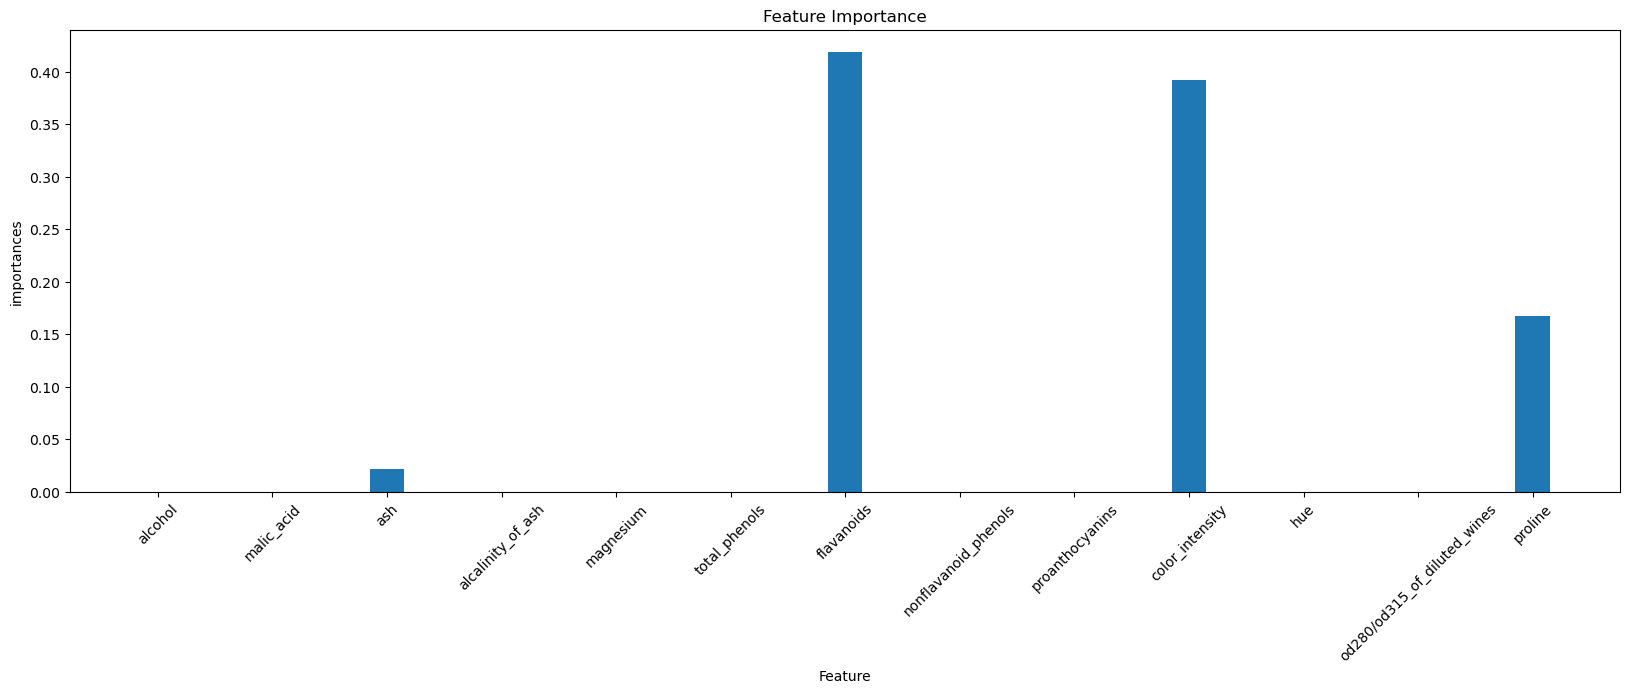

In [3]:
''' 코드를 작성해주세요 '''

# GridSearch
param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# HPO 및 Fitting
clf = DecisionTreeClassifier(random_state= 42)
grid_search = GridSearchCV(clf, param_grid, cv= 5)
grid_search.fit(X_train, y_train)

print("Best Hyper-parameter", grid_search.best_params_)
print("Best Score", grid_search.best_score_)

# HPO만들어진 모형의 정확도 계산 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
# print('Accuracy Grid :', accuracy)

# Feature Importance 시각화
importances = best_model.feature_importances_

plt.figure(figsize = (20,6))
plt.bar(range(len(importances)), importances, width=0.3)
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.show()

# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


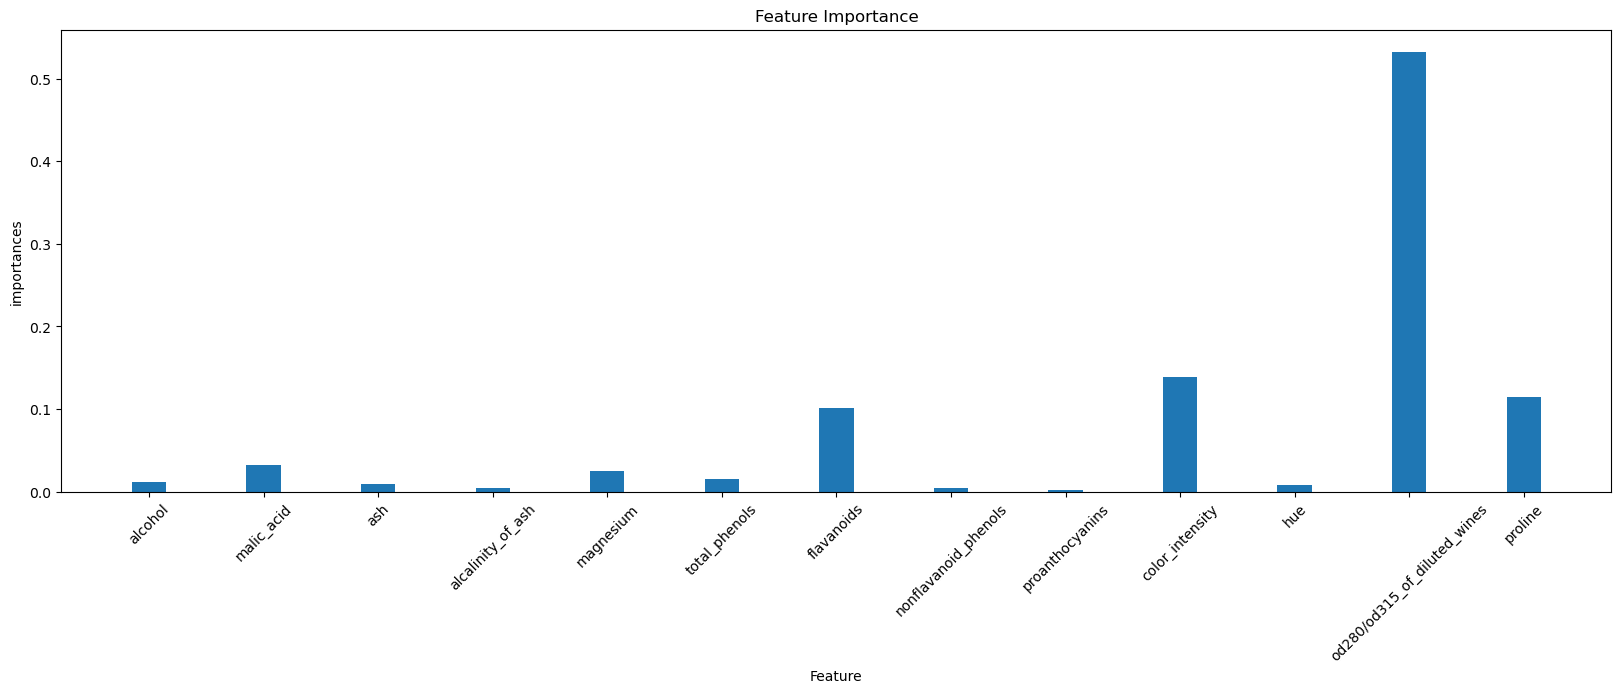

In [10]:
''' 코드를 작성해주세요 '''

# XGboost 모델 생성
xgb_model = XGBClassifier(random_state=42)

# 하이퍼파라미터 범위지정
xgb_params = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

# 하이퍼파라미터 최적화 및 학습
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=xgb_params, cv=5, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

print("Best parameters:", grid_search_xgb.best_params_)
print("Best accuracy:", grid_search_xgb.best_score_)

# 테스트 데이터에 대한 예측
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
# print('Accuracy Grid :', accuracy_xgb)

# Feature Importance 시각화
importances_xgb = best_xgb_model.feature_importances_

plt.figure(figsize = (20,6))
plt.bar(range(len(importances_xgb)), importances_xgb, width=0.3)
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances_xgb)), X.columns, rotation = 45)
plt.show()

# 성능 비교 시각화

============================== DT 성능 확인 ==============================
DT accuracy : 0.9444444444444444
Classification Report               precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

============================== XGB 성능 확인 ==============================
XGB accuracy : 0.9722222222222222
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      

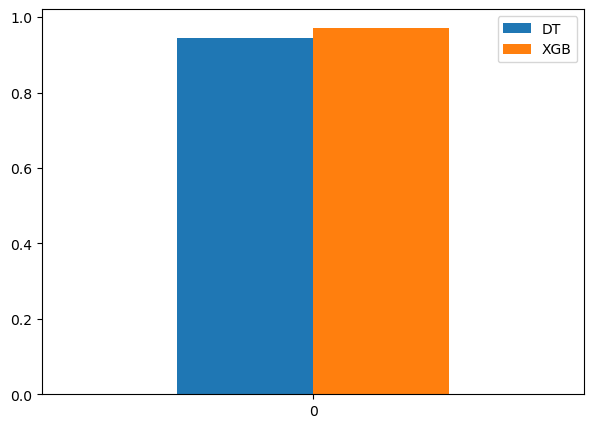

In [47]:
''' 코드를 작성해주세요 '''
print("="*30, "DT 성능 확인", "="*30)
print('DT accuracy :', accuracy)
print("Classification Report", classification_report(y_test, y_pred))

print("="*30, "XGB 성능 확인", "="*30)
print('XGB accuracy :', accuracy_xgb)
print("Classification Report", classification_report(y_test, y_pred_xgb))

plt.figure(figsize = (7,5))
plt.bar(0-0.25, accuracy, 0.5, label='DT')
plt.bar(0+0.25, accuracy_xgb, 0.5, label='XGB')
plt.xticks([0])  
plt.xlim(-1, 1) 
plt.legend()
plt.show()